### This example uses undersampling for a regression dataset

**Undersampling is usually more simple in classification dataset, since no binning needs to be done**

In [162]:
import pandas as pd
import numpy as np
import seaborn as sns

# pip install imblearn
from imblearn.under_sampling import RandomUnderSampler

# switch to decimal format in pandas for easier values in describe()
pd.set_option('display.float_format', '{:.2f}'.format)

# load the data
df = pd.read_csv("../houses.csv")
df = df.drop(["id", "date", "zipcode", "lat", "long"], axis=1)
df.head()

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,sqft_living15,sqft_lot15
0,221900.00,3,1.00,1180,5650,1.00,0,0,3,7,1180,0,1955,0,1340,5650
1,538000.00,3,2.25,2570,7242,2.00,0,0,3,7,2170,400,1951,1991,1690,7639
2,180000.00,2,1.00,770,10000,1.00,0,0,3,6,770,0,1933,0,2720,8062
3,604000.00,4,3.00,1960,5000,1.00,0,0,5,7,1050,910,1965,0,1360,5000
4,510000.00,3,2.00,1680,8080,1.00,0,0,3,8,1680,0,1987,0,1800,7503


### Original target distribution in house dataset

<Axes: xlabel='price', ylabel='Count'>

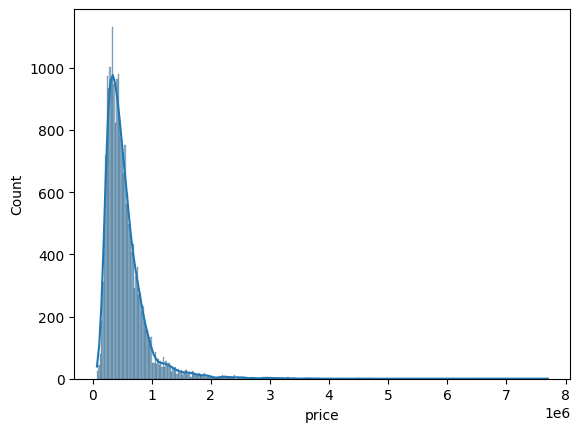

In [163]:
sns.histplot(data=df, x='price', kde=True)

**This dataset has over 21k+ houses, so undersampling can be beneficial**

Isolation Forest, IQR etc. it's possible to use multiple outlier removal tools at once too, but often one is enough (like Isolation Forest)

In [164]:
# can process the whole dataset 
# and compares variables to each other instead
# of focusing on outliers on a single variable
from sklearn.ensemble import IsolationForest
import pandas as pd

# adjust the contamination rate as you see fit
# for example, if you expect 5% of the data to be outliers
# you can use 0.05 etc. 

# basically, this is how aggressive Isolation Forest will be
# increase if you think you need to detect more outliers
# decrease if you need less outliers
iso = IsolationForest(contamination=0.1) 

# fit isolation forest
y_pred = iso.fit_predict(df)

# separate outliers and inliers into separate DataFrames
outliers = df[y_pred != 1]
inliers = df[y_pred == 1]

print(f"Inliers: {len(inliers)}")
print(f"Outliers: {len(outliers)}")

# use the inliers as the new DataFrame
df = inliers

Inliers: 19451
Outliers: 2162


<Axes: xlabel='price', ylabel='Count'>

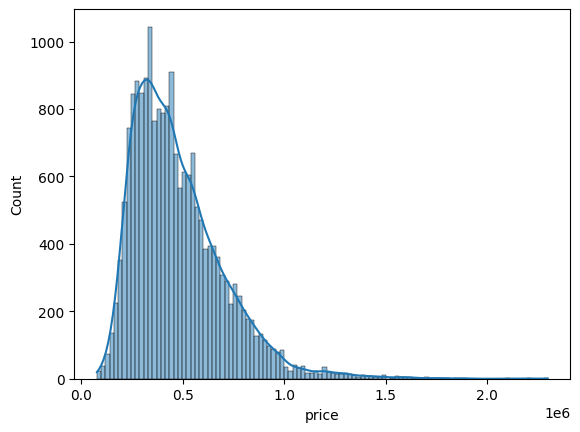

In [165]:
sns.histplot(data=df, x='price', kde=True)

In [166]:
import numpy as np
import pandas as pd

# load dataset
variable = "price"

# Calculate Q1 and Q3, adjust for a more subtle outlier detection
# in this case, we preserve everything from the left side (quantile(0))
# and target the top 30% of the quantile (0.7)
Q1 = df[variable].quantile(0)
Q3 = df[variable].quantile(0.8)

# Calculate IQR
IQR = Q3 - Q1

# Define bounds for outliers
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Detect outliers
outliers = df[(df[variable] < lower_bound) | (df[variable] > upper_bound)]
df = df.drop(outliers.index)

<Axes: xlabel='price', ylabel='Count'>

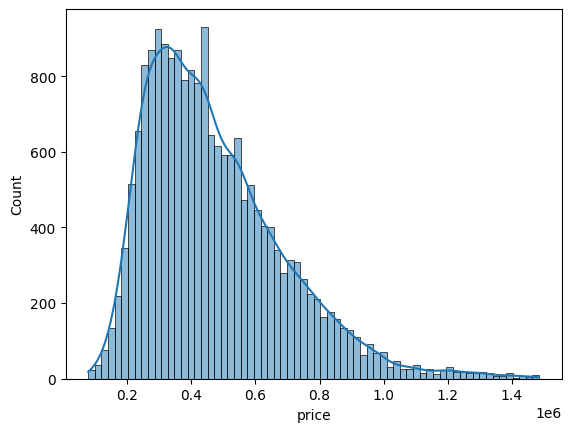

In [167]:
sns.histplot(data=df, x='price', kde=True)

## Undersampling (RandomUnderSampling)

Undersampling techniques usually work only on categorical targets, which is a problem, because this is a regression dataset (target is continuous).

In [168]:
# create a temporary variable -> target_binned
# use enough categories to capture most of the trends in the target
target = "price"
df['target_binned'] = pd.cut(df[target], bins=8, labels=False)

<Axes: xlabel='target_binned', ylabel='Count'>

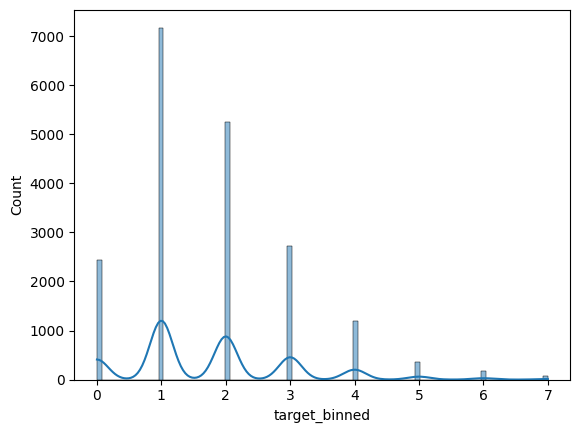

In [169]:
sns.histplot(data=df, x='target_binned', kde=True)

In [170]:
# we need to know how much data each bin contains
# so we know how much data we can reduce eventually
df['target_binned'].value_counts().sort_index()

target_binned
0    2442
1    7175
2    5258
3    2720
4    1203
5     357
6     166
7      75
Name: count, dtype: int64

**Actual undersampling**

In [171]:
# we need X/y -split here
variables = df.drop('target_binned', axis=1).columns

X = df[variables]
y = df['target_binned']

# initialize the undersampler
# it's better to specify a sampling strategy
# since the default sampler removed 95% of our data
strategy = {
    0: 400,
    1: 1200,
    2: 2000,
    3: 1200,
    4: 800,
    5: 300,
    6: 130,
    7: 60

}

sampler = RandomUnderSampler(sampling_strategy=strategy, random_state=321)

# perform undersampling
X_resampled, y_resampled = sampler.fit_resample(X, y)

# reconstruct the dataframe
df_resampled = pd.DataFrame(X_resampled, columns=variables)

# if you still need the binned target for regression
# you can use this, but you can also leave it out
df_resampled['target_binned'] = y_resampled

In [172]:
len(df)

19396

In [173]:
len(df_resampled)

6090

<Axes: xlabel='price', ylabel='Count'>

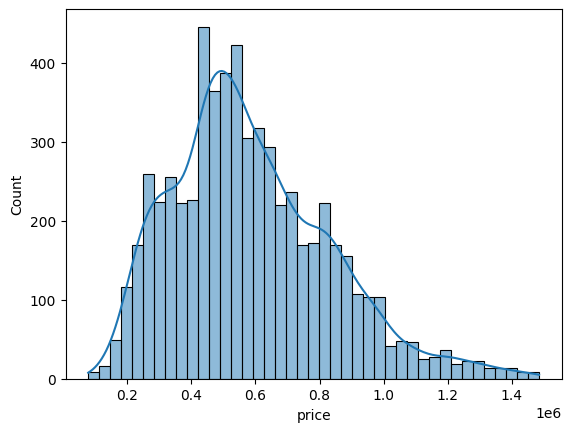

In [174]:
sns.histplot(data=df_resampled, x='price', kde=True)

In [175]:
df.describe()

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,sqft_living15,sqft_lot15,target_binned
count,19396.00,19396.00,19396.00,19396.00,19396.00,19396.00,19396.00,19396.00,19396.00,19396.00,19396.00,19396.00,19396.00,19396.00,19396.00,19396.00,19396.00
mean,474106.03,3.31,2.03,1936.39,10030.74,1.47,0.00,0.12,3.41,7.52,1684.04,252.35,1971.59,31.39,1904.03,9268.03,1.75
std,216767.16,0.87,0.68,722.31,12620.11,0.54,0.00,0.51,0.64,1.01,695.85,387.18,28.76,248.35,594.47,10116.93,1.26
min,78000.00,0.00,0.00,380.00,520.00,1.00,0.00,0.00,1.00,4.00,380.00,0.00,1900.00,0.00,460.00,651.00,0.00
25%,312000.00,3.00,1.50,1390.00,5000.00,1.00,0.00,0.00,3.00,7.00,1170.00,0.00,1953.00,0.00,1460.00,5000.75,1.00
50%,430000.00,3.00,2.00,1830.00,7410.00,1.00,0.00,0.00,3.00,7.00,1500.00,0.00,1975.00,0.00,1790.00,7491.50,2.00
75%,592387.50,4.00,2.50,2390.00,9972.00,2.00,0.00,0.00,4.00,8.00,2070.00,500.00,1997.00,0.00,2250.00,9626.25,2.00
max,1485000.00,33.00,5.25,4930.00,223462.00,3.50,0.00,4.00,5.00,11.00,4620.00,2170.00,2015.00,2015.00,4650.00,215622.00,7.00


In [176]:
df_resampled.describe()

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,sqft_living15,sqft_lot15,target_binned
count,6090.00,6090.00,6090.00,6090.00,6090.00,6090.00,6090.00,6090.00,6090.00,6090.00,6090.00,6090.00,6090.00,6090.00,6090.00,6090.00,6090.00
mean,586187.30,3.45,2.18,2162.42,10642.23,1.54,0.00,0.18,3.43,7.83,1869.95,292.46,1972.52,28.90,2066.72,9643.27,2.41
std,247500.27,0.93,0.69,774.97,13767.53,0.53,0.00,0.61,0.65,1.08,774.38,416.44,29.98,238.71,652.34,10361.86,1.43
min,78000.00,0.00,0.00,480.00,520.00,1.00,0.00,0.00,1.00,4.00,480.00,0.00,1900.00,0.00,620.00,750.00,0.00
25%,419000.00,3.00,1.75,1560.00,5000.00,1.00,0.00,0.00,3.00,7.00,1260.00,0.00,1952.00,0.00,1560.00,5000.00,1.00
50%,549000.00,3.00,2.25,2080.00,7452.50,1.50,0.00,0.00,3.00,8.00,1680.00,0.00,1977.00,0.00,1952.50,7477.00,2.00
75%,736375.00,4.00,2.50,2680.00,10293.75,2.00,0.00,0.00,4.00,8.00,2380.00,600.00,1999.00,0.00,2499.00,9997.75,3.00
max,1485000.00,33.00,5.00,4680.00,223462.00,3.50,0.00,4.00,5.00,11.00,4620.00,2170.00,2015.00,2015.00,4610.00,196591.00,7.00


In [177]:
df.corr()['price']

price           1.00
bedrooms        0.28
bathrooms       0.42
sqft_living     0.60
sqft_lot        0.08
floors          0.27
waterfront       NaN
view            0.19
condition       0.04
grade           0.63
sqft_above      0.52
sqft_basement   0.20
yr_built        0.07
yr_renovated    0.00
sqft_living15   0.55
sqft_lot15      0.06
target_binned   0.97
Name: price, dtype: float64

In [178]:
df_resampled.corr()['price']

price            1.00
bedrooms         0.27
bathrooms        0.42
sqft_living      0.61
sqft_lot         0.05
floors           0.27
waterfront        NaN
view             0.16
condition        0.04
grade            0.63
sqft_above       0.52
sqft_basement    0.16
yr_built         0.06
yr_renovated    -0.00
sqft_living15    0.54
sqft_lot15       0.06
target_binned    0.98
Name: price, dtype: float64

**Since we altered the target distribution heavilt, we can expect basic statistics like mean, median, standard deviation and variation to change.**

However, correlations are surprisingly close to original! (which is promising)

You can also check the phik-matrix before and after resampling etc.